In [1]:
import matplotlib.pyplot as plt
import numpy as np
import os
import csv
from scipy.stats import linregress
import matplotlib as mpl
mpl.rcParams['font.family'] = 'Arial'

In [2]:
def read_correlation_datafiles(path, file):
    
    dataset_date = path.split('/')[-1]
    datafolder = os.path.join(path)
    os.chdir(datafolder)
    #print(os.getcwd())

    files_in_folder = os.listdir()
    file_to_open = file
    #print(files_in_folder)
    
    correlation_data_all = []
    correlation_data_all.append(["cell", "index", "pearson_r", "expression", "IoU"])
    #'Cell', 'Index', 'Pearson_r', 'Expression', 'IoU'
    
    with open(file_to_open, "r") as f:
                reader = csv.reader(f, delimiter="\t")
                next(reader) # Skip the first row
                #Loop through the rows in the file and append the data
                for row in reader:
                    #print(row)
                    correlation_data_all.append([row[0], row[1], row[2], row[3], row[4]])
                    
    print(path, file, "read")
    return(correlation_data_all)

In [3]:
path_Nup98KDM5A_mEGFP_H3K4me3AF546 = 'D:/Augusto/PythonCode/Figure1/NSPARC_Nup98_KDM5A_Correlation_Analysis/20250111_mEGFP/Nup98-KDM5A-mEGFP-H3K4me3-AF546'
file_Nup98KDM5A_mEGFP_H3K4me3AF546 = 'megfp_546_norm_withiou.txt'

path_Nup98KDM5Amut_mEGFP_H3K4me3AF546 = 'D:/Augusto/PythonCode/Figure1/NSPARC_Nup98_KDM5A_Correlation_Analysis/20250112_mut_mEGFP/Nup98-KDM5Amut-mEGFP-H3K4me3-AF546/'
file_Nup98KDM5Amut_mEGFP_H3K4me3AF546 = 'megfpmut_546_with_iou.txt'

In [4]:
correlation_Nup98KDM5A_mEGFP_H3K4me3AF546 = read_correlation_datafiles(path_Nup98KDM5A_mEGFP_H3K4me3AF546, file_Nup98KDM5A_mEGFP_H3K4me3AF546)
correlation_Nup98KDM5Amut_mEGFP_H3K4me3AF546 = read_correlation_datafiles(path_Nup98KDM5Amut_mEGFP_H3K4me3AF546, file_Nup98KDM5Amut_mEGFP_H3K4me3AF546)


D:/Augusto/PythonCode/Figure1/NSPARC_Nup98_KDM5A_Correlation_Analysis/20250111_mEGFP/Nup98-KDM5A-mEGFP-H3K4me3-AF546 megfp_546_norm_withiou.txt read
D:/Augusto/PythonCode/Figure1/NSPARC_Nup98_KDM5A_Correlation_Analysis/20250112_mut_mEGFP/Nup98-KDM5Amut-mEGFP-H3K4me3-AF546/ megfpmut_546_with_iou.txt read


In [5]:
expression_Nup98KDM5A_mEGFP_H3K4me3AF546 =  np.array([row[3] for row in correlation_Nup98KDM5A_mEGFP_H3K4me3AF546[1:]], dtype=float)
pearson_Nup98KDM5A_mEGFP_H3K4me3AF546 = np.array([row[2] for row in correlation_Nup98KDM5A_mEGFP_H3K4me3AF546[1:]], dtype=float)

expression_Nup98KDM5Amut_mEGFP_H3K4me3AF546 =  np.array([row[3] for row in correlation_Nup98KDM5Amut_mEGFP_H3K4me3AF546[1:]], dtype=float)
pearson_Nup98KDM5Amut_mEGFP_H3K4me3AF546 = np.array([row[2] for row in correlation_Nup98KDM5Amut_mEGFP_H3K4me3AF546[1:]], dtype=float)

#print(np.array(expression_Nup98KDM5A_mEGFP_H3K4me3AF546))

In [6]:
#Color palettes
#https://colorany.com/color-palettes/colorblind-friendly-color-palettes/

Nup98_KDM5A_mEGFP_color = '#6AB04C'
Nup98_KDM5Amut_mEGFP_color = '#3D5B99'

#Labels
#n for each dataset
n_Nup98_KDM5A_mEGFP = len(expression_Nup98KDM5A_mEGFP_H3K4me3AF546)
n_Nup98_KDM5Amut_mEGFP = len(expression_Nup98KDM5Amut_mEGFP_H3K4me3AF546)

#label
label_Nup98_KDM5A_mEGFP = "Nup98-KDM5A-mEGFP, n = " + str(n_Nup98_KDM5A_mEGFP)
label_Nup98_KDM5Amut_mEGFP = "Nup98-KDM5Amut-mEGFP, n = " + str(n_Nup98_KDM5Amut_mEGFP)

#legend handles
legend_handles = [
    plt.Line2D([], [], marker='o', markerfacecolor=Nup98_KDM5A_mEGFP_color, color='None', linestyle='None', label=label_Nup98_KDM5A_mEGFP),
    plt.Line2D([], [], marker='o', markerfacecolor=Nup98_KDM5Amut_mEGFP_color, color='None', linestyle='None', label=label_Nup98_KDM5Amut_mEGFP),
]


In [7]:
#Figure outputs

output_path = "D:/Augusto/PythonCode/Figure1/"

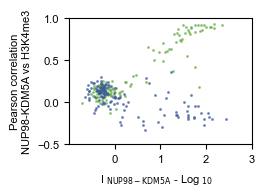

In [8]:
##Aug 31st, 2025

###Correlation 
fig, ax = plt.subplots(1, 1, figsize=(2.75, 1.8))

fig.text(0.38, 0, 'I $_{\mathrm{NUP98-KDM5A}}$ - Log $_{\mathrm{10}}$', va='center', rotation='horizontal', fontsize=8, fontname="Arial")

sc1 = ax.scatter(np.log10(expression_Nup98KDM5A_mEGFP_H3K4me3AF546), pearson_Nup98KDM5A_mEGFP_H3K4me3AF546,
                 marker = ".", c = Nup98_KDM5A_mEGFP_color, s = 5,
                 alpha = 0.6, label='Nup98-KDM5A-mEGFP')

sc2 = ax.scatter(np.log10(expression_Nup98KDM5Amut_mEGFP_H3K4me3AF546), pearson_Nup98KDM5Amut_mEGFP_H3K4me3AF546,
                 marker = ".", c = Nup98_KDM5Amut_mEGFP_color, s = 5, 
                 alpha = 0.6, label='Nup98-KDM5Amut-mEGFP')

# Add legend handles to the plot
#plt.legend(handles=legend_handles, loc='upper left', fontsize = 6)

# Set the plot title and labels
#NSPARC data
#ax.set_xlabel('Mean Nup98-KDM5A intensity (au)-Log 10', fontsize=10, fontname="Arial")
ax.set_ylabel('Pearson correlation\nNUP98-KDM5A vs H3K4me3', fontsize=8, fontname="Arial")

# # Set x-axis limits from 0 to 500 nM
ax.set_xlim(-1, 3)
ax.set_ylim(-0.5, 1)  

ax.set_xticks([0, 1, 2, 3])   # X-axis ticks
ax.set_yticks([-0.5, 0, 0.5, 1])  # Y-axis ticks

ax.tick_params(axis='x', labelsize=8)
ax.tick_params(axis='y', labelsize=8)

# Show the plot
#plt.grid()
fig.tight_layout()
plt.show()

# Save as PNG, 300 dpi is publication quality
image_file_name = output_path + "Combined_Pearson.png"
fig.savefig(image_file_name, bbox_inches='tight', pad_inches=0.1, dpi=300, format="png")
plt.close(fig)